In [1]:
import numpy as np

import matplotlib.pyplot as plt
import japanize_matplotlib

In [2]:
from thinkbayes import _DictWrapper

class Pmf(_DictWrapper):

    def Normalize(self, fraction=1.0):
        if self.log:
            raise ValueError("Pmf is under a log transforms")
        total = self.Total()
        if total == 0.0:
            raise ValueError("total probability is zero")
            return total
        factor = float(fraction)/total
        for x in self.d:
            self.d[x] *=factor
        return total

    def Mean(self):
        mu = 0.0
        for x, p in self.d.items():
            mu += p*x
        return mu

    def MakeCdf(self, name=None):
        return MakeCdfFromPmf(self, name=name)

def MakeCdfFromPmf(pmf, name=None):
    if name == None:
        name = pmf.name
    return MakeCdfFromItems(pmf.Items(), name)

def MakeCdfFromItems(items, name=''):
    runsum = 0
    xs = []
    cs = []

    for value, count in sorted(items):
        runsum += count
        xs.append(value)
        cs.append(runsum)

    total = float(runsum)
    ps = [c/total for c in cs]
    cdf = Cdf(xs, ps, name)
    return cdf

    

class Suite(Pmf):
    def Update(self, data):
        for hypo in list(self.Values()):
            like = self.Likelihood(data, hypo)
            self.Mult(hypo, like)
        return self.Normalize()


In [3]:
class Train(Suite):
    def Likelihood(self, data, hypo):
        if hypo < data:
            return 0
        else:
            return 1.0/hypo

In [4]:
class Dice(Suite):
    def Likelihood(self, data, hypo):
        if hypo < data:
            return 0
        else:
            return 1.0/hypo

In [5]:
class Cdf(object):
    def __init__(self, xs=None, ps=None, name=''):
        self.xs = [] if xs is None else xs
        self.ps = [] if ps is None else ps
        self.name = name


In [6]:
hypos = np.arange(1,1001)

suite = Train(hypos)
suite.Update(60)

0.0028222671142652746

Text(0.5, 1.0, '一様な事前分布に基づいた機関車問題の事後確率分布')

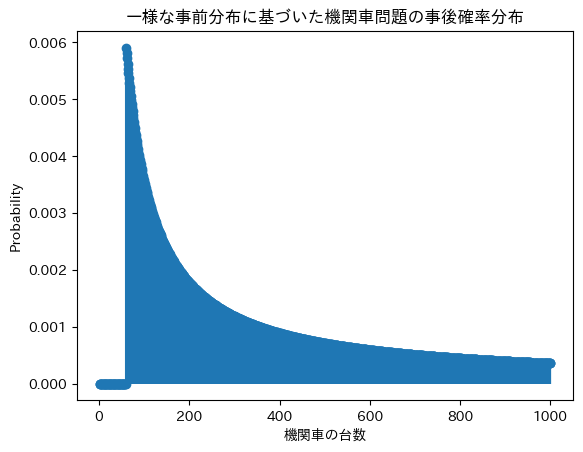

In [7]:
k, v = zip(*suite.Items())

plt.vlines(k,0,v)
plt.plot(k,v, 'o')
plt.xlabel('機関車の台数')
plt.ylabel('Probability')
plt.title("一様な事前分布に基づいた機関車問題の事後確率分布")

In [8]:
total = 0
for hypo, prob in suite.Items():
    total += hypo * prob

print(f"Mean: {total:.0f}")

Mean: 333


In [9]:
for max_train in [501,1001,2001]:
    hypos = np.arange(1,max_train)
    suite = Train(hypos)

    for data in [60, 30, 90]:
        suite.Update(data)

    total = 0
    for hypo, prob in suite.Items():
        total += hypo * prob
    print(f"Mean: {total:.0f}")

Mean: 152
Mean: 164
Mean: 171


In [10]:
class Train2(Dice):
    def __init__(self, hypos, alpha=1.0):
        Pmf.__init__(self)
        for hypo in hypos:
            self.Set(hypo, hypo**(-alpha))
        self.Normalize()

In [11]:
hypos = np.arange(1,1001)
suite2 = Train2(hypos)

Text(0.5, 1.0, '一様な事前分布に基づいた機関車問題の事後確率分布')

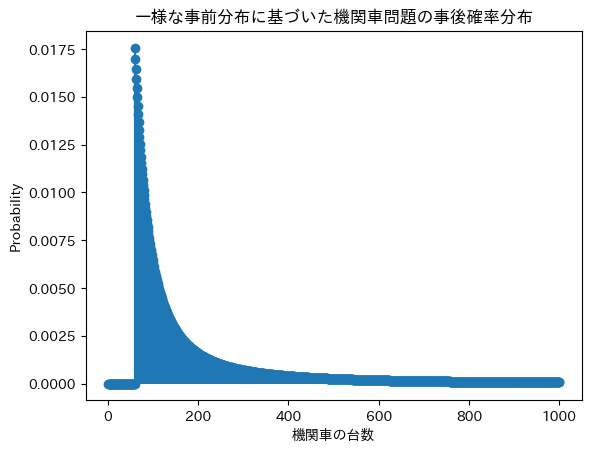

In [12]:
suite2.Update(60)

k, v = zip(*suite2.Items())

plt.vlines(k,0,v)
plt.plot(k,v, 'o')
plt.xlabel('機関車の台数')
plt.ylabel('Probability')
plt.title("一様な事前分布に基づいた機関車問題の事後確率分布")

In [13]:
for max_train in [501,1001,2001]:  
    hypos = np.arange(1,max_train)
    suite2 = Train2(hypos)

    for data in [60, 30, 90]:
        suite2.Update(data)
        total = 0
        
    for hypo, prob in suite2.Items():
        total += hypo * prob

    print(f"Mean: {total:.0f}")

Mean: 131
Mean: 133
Mean: 134


In [14]:
def Percentile(pmf, percentage):
    p = percentage / 100.0
    total = 0
    for val, prob in pmf.Items():
        total += prob
        if total >= p:
            return val

In [15]:
interval = Percentile(suite2,5), Percentile(suite2,95)
interval

(91, 243)

91 243


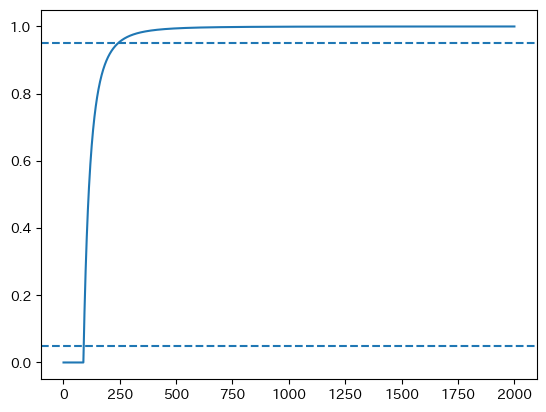

In [16]:
cdf = suite2.MakeCdf()

xs,ps = cdf.xs, cdf.ps

p05 = xs[next(i for i, p in enumerate(ps) if p >= 0.05)]
p50 = xs[next(i for i, p in enumerate(ps) if p >= 0.5)]
p95 = xs[next(i for i, p in enumerate(ps) if p >= 0.95)]

print(p05, p95)

plt.plot(xs,ps)

# 5% と 95% の線
plt.axhline(0.05, linestyle='--')
plt.axhline(0.95, linestyle='--')

In [17]:
for i, p in enumerate(ps):
    if p >= 0.5:
        p50 = xs[i]
        break
p50

113